# Homework 1 — Problem 3: ResNet-11 vs ResNet-18 on CIFAR-10

**Author:** *(your name)*  
**Student ID:** *(your ID)*  
**GitHub:** *(your repo link)*  
**Seed:** 42 | **Batch size:** 128 | **Device:** auto-detected below

---

### Notebook structure
| Cell | Contents | Est. Time |
|------|----------|-----------|
| 1 | Device check + all imports | ~5 sec |
| 2 | Data setup | ~10 sec |
| 3 | ResNet-11 architecture + training (50 epochs) | ~90 min |
| 4 | ResNet-18 architecture + training (50 epochs) | ~120 min |
| 5 | Part A — evaluation, curves, confusion matrices, comparison table | ~5 min |
| 6 | Part B — dropout on ResNet-11 (p=0.3, p=0.5) | ~3 hrs |
| 7 | Part B — dropout on ResNet-18 (p=0.3, p=0.5) | ~4 hrs |
| 8 | Final 4-architecture comparison bar chart + summary table | ~2 min |

---

### Key architectural decisions grounded in references

**ResNet paper (He et al., 2015):** Skip connections let gradients bypass layers through
identity mappings, solving the vanishing gradient problem that prevented training very deep networks.

**Identity Mappings paper (He et al., 2016):** Forward and backward signals propagate
directly from any block to any other when using identity mappings as skip connections.

**Dropout vs BN paper (Li et al., 2018):** Dropout before BN causes variance shift between
train and test — this is why dropout hurts ResNet more than AlexNet/VGGNet.

**CIFAR-10 adaptation (both models):** Replace standard 7×7 conv + maxpool with a single
3×3 conv and no pooling — preserves spatial information at 32×32 resolution.


## Cell 1 — Device Check & Imports

In [2]:
import os, time, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchinfo import summary as torchinfo_summary
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Device check ──────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 55)
print("  DEVICE CHECK")
print("=" * 55)
print(f"  CUDA available : {torch.cuda.is_available()}")
print(f"  Active device  : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU            : {torch.cuda.get_device_name(0)}")
    print(f"  GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print("  ✅ Running on GPU")
else:
    print("  ⚠️  Running on CPU — check kernel selection (top right)")
print("=" * 55)
assert DEVICE.type == "cuda", "❌ Switch kernel to 'Python 3.12 (deep learning)' and restart."


  DEVICE CHECK
  CUDA available : True
  Active device  : cuda
  GPU            : NVIDIA GeForce MX250
  GPU memory     : 2.1 GB
  ✅ Running on GPU


## Cell 2 — Data Setup
Identical pipeline to Problems 1 & 2 — same seed, same split, same transforms.

In [3]:
# ── Global config ─────────────────────────────────────────────────────────────
RANDOM_SEED  = 42
BATCH_SIZE   = 128
NUM_WORKERS  = 0
VAL_FRACTION = 0.1
DATA_DIR     = "./data"

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

def get_cifar10_loaders(data_dir=DATA_DIR, batch_size=BATCH_SIZE,
                        val_fraction=VAL_FRACTION, seed=RANDOM_SEED,
                        num_workers=NUM_WORKERS):
    torch.manual_seed(seed)
    np.random.seed(seed)
    full_train_aug  = datasets.CIFAR10(data_dir, train=True,  download=True,  transform=train_transform)
    full_train_eval = datasets.CIFAR10(data_dir, train=True,  download=False, transform=eval_transform)
    test_dataset    = datasets.CIFAR10(data_dir, train=False, download=False, transform=eval_transform)
    n_total = len(full_train_aug)
    n_val   = int(n_total * val_fraction)
    rng     = np.random.default_rng(seed)
    indices = rng.permutation(n_total)
    train_indices, val_indices = indices[:n_total-n_val], indices[n_total-n_val:]
    train_loader = DataLoader(Subset(full_train_aug,  train_indices),
                              batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, drop_last=True)
    val_loader   = DataLoader(Subset(full_train_eval, val_indices),
                              batch_size=batch_size, shuffle=False,
                              num_workers=num_workers)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size,
                              shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader

def set_seed(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

train_loader, val_loader, test_loader = get_cifar10_loaders()
print(f"Seed          : {RANDOM_SEED}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Train batches : {len(train_loader)}  ({len(train_loader.dataset):,} samples)")
print(f"Val   batches : {len(val_loader)}  ({len(val_loader.dataset):,} samples)")
print(f"Test  batches : {len(test_loader)}  ({len(test_loader.dataset):,} samples)")
images, labels = next(iter(train_loader))
print(f"Batch shape   : {images.shape}")
print(f"Pixel range   : {images.min():.3f} / {images.max():.3f}")
print("✅ Data setup ready.")


Seed          : 42
Batch size    : 128
Train batches : 351  (45,000 samples)
Val   batches : 40  (5,000 samples)
Test  batches : 79  (10,000 samples)
Batch shape   : torch.Size([128, 3, 32, 32])
Pixel range   : -1.989 / 2.126
✅ Data setup ready.


## Cell 3 — ResNet-11: Architecture & Training

**ResNet-11 architecture:**
- CIFAR-10 stem: 3×3 conv, 16 filters, stride 1, no pooling
- Stage 1: 1× BasicBlock, 16 filters, stride 1
- Stage 2: 1× BasicBlock, 32 filters, stride 2 (downsamples)
- Stage 3: 1× BasicBlock, 64 filters, stride 2 (downsamples)
- Global average pooling → FC(10)
- Total: ~180k parameters

**BasicBlock structure (from ResNet paper):**
Conv3×3 → BN → ReLU → Conv3×3 → BN → [skip] → ReLU

**Skip connection:** identity when dimensions match; 1×1 conv + BN when they don't.


In [4]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
SEED         = 42
NUM_EPOCHS   = 50
LR           = 0.1        # ResNet paper uses 0.1 with cosine/step decay
MOMENTUM     = 0.9
WEIGHT_DECAY = 5e-4
NUM_CLASSES  = 10
SAVE_DIR_R11 = "./outputs_r11"
os.makedirs(SAVE_DIR_R11, exist_ok=True)

# ── BasicBlock ────────────────────────────────────────────────────────────────
class BasicBlock(nn.Module):
    """
    ResNet BasicBlock: two 3x3 conv layers with BN and a skip connection.

    Skip connection options:
      - Identity: when in_channels == out_channels and stride == 1
      - Projection: 1x1 conv + BN when dimensions change (stride>1 or channel change)

    From He et al. (2015): 'The shortcut connections simply perform identity
    mapping, and their outputs are added to the outputs of the stacked layers.'
    """
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # Shortcut: projection needed when spatial dims or channels change
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)   # skip connection
        out = self.relu(out)
        return out

# ── ResNet-11 ─────────────────────────────────────────────────────────────────
class ResNet11(nn.Module):
    """
    ResNet-11 for CIFAR-10.

    Layer count: 1 stem + (1+1)*3 stages + 1 FC = 1 + 6 + 1 = 8 weight layers
    With BN layers counted: commonly called ResNet-11 in course materials.

    Spatial flow:
      Input    : 3  x 32 x 32
      Stem     : 16 x 32 x 32  (3x3 conv, no pool — CIFAR-10 adaptation)
      Stage 1  : 16 x 32 x 32  (stride 1, no downsample)
      Stage 2  : 32 x 16 x 16  (stride 2, downsample)
      Stage 3  : 64 x  8 x  8  (stride 2, downsample)
      GAP      : 64 x  1 x  1
      FC       : 10
    """
    def __init__(self, num_classes=NUM_CLASSES, dropout_p=0.0):
        super().__init__()
        self.dropout_p = dropout_p

        # CIFAR-10 stem: 3x3 conv instead of 7x7, no maxpool
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )

        # Residual stages
        self.stage1 = self._make_stage(16, 16, stride=1, num_blocks=1)
        self.stage2 = self._make_stage(16, 32, stride=2, num_blocks=1)
        self.stage3 = self._make_stage(32, 64, stride=2, num_blocks=1)

        # Global average pooling + classifier
        self.gap        = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout    = nn.Dropout(p=dropout_p)
        self.classifier = nn.Linear(64, num_classes)

        self._init_weights()

    def _make_stage(self, in_ch, out_ch, stride, num_blocks):
        blocks = [BasicBlock(in_ch, out_ch, stride=stride)]
        for _ in range(1, num_blocks):
            blocks.append(BasicBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*blocks)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                        nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias,   0.0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                        nonlinearity="relu")
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.classifier(x)

# ── Shared training utilities ─────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += out.max(1)[1].eq(labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        out  = model(images)
        loss = criterion(out, labels)
        total_loss += loss.item() * images.size(0)
        correct    += out.max(1)[1].eq(labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def get_all_predictions(model, loader, device):
    model.eval()
    all_labels, all_preds = [], []
    for images, labels in loader:
        out = model(images.to(device))
        all_preds.extend(out.max(1)[1].cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

def run_training(model, train_loader, val_loader,
                 num_epochs=NUM_EPOCHS, lr=LR,
                 label="model", save_dir="./outputs"):
    os.makedirs(save_dir, exist_ok=True)
    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr,
                          momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    # Cosine annealing — standard for ResNet on CIFAR-10
    # Smoothly decays LR from initial value to near-zero over all epochs
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-4)

    history  = dict(train_loss=[], val_loss=[],
                    train_acc=[], val_acc=[], epoch_times=[])
    best_val = 0.0
    ckpt     = os.path.join(save_dir, f"{label}_best.pt")

    print(f"\nTraining : {label}")
    print(f"Device   : {DEVICE}  |  Epochs: {num_epochs}  |  LR: {lr}  |  BS: {BATCH_SIZE}")
    print(f"Scheduler: CosineAnnealingLR  T_max={num_epochs}  eta_min=1e-4")
    print(f"{'─'*75}")

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        vl, va = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()
        elapsed = time.time() - t0

        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)
        history["epoch_times"].append(elapsed)

        if va > best_val:
            best_val = va
            torch.save(model.state_dict(), ckpt)

        print(f"Epoch [{epoch:3d}/{num_epochs}]  "
              f"Train Loss: {tl:.4f}  Acc: {ta*100:.2f}%  |  "
              f"Val Loss: {vl:.4f}  Acc: {va*100:.2f}%  |  "
              f"LR: {scheduler.get_last_lr()[0]:.5f}  ({elapsed:.1f}s)")

    print(f"{'─'*75}")
    print(f"Best val accuracy : {best_val*100:.2f}%  →  {ckpt}\n")
    return history, ckpt

# ── torchinfo summary ─────────────────────────────────────────────────────────
print("=" * 60)
print("  ResNet-11 — Architecture Summary")
print("=" * 60)
set_seed(SEED)
model_r11 = ResNet11(num_classes=NUM_CLASSES, dropout_p=0.0)
torchinfo_summary(model_r11, input_size=(1, 3, 32, 32),
                  col_names=["input_size", "output_size", "num_params"],
                  verbose=1, device=DEVICE)
params_r11 = sum(p.numel() for p in model_r11.parameters() if p.requires_grad)
print(f"\nResNet-11 trainable params: {params_r11:,}")

# ── Init + device check ───────────────────────────────────────────────────────
first_conv = next(m for m in model_r11.modules() if isinstance(m, nn.Conv2d))
print(f"Init check — weight std : {first_conv.weight.std().item():.4f}")
print()

# ── Train ─────────────────────────────────────────────────────────────────────
set_seed(SEED)
history_r11, ckpt_r11 = run_training(
    model_r11, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=LR,
    label="resnet11_baseline", save_dir=SAVE_DIR_R11
)
print("✅ ResNet-11 training complete.")


  ResNet-11 — Architecture Summary
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ResNet11                                 [1, 3, 32, 32]            [1, 10]                   --
├─Sequential: 1-1                        [1, 3, 32, 32]            [1, 16, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 3, 32, 32]            [1, 16, 32, 32]           432
│    └─BatchNorm2d: 2-2                  [1, 16, 32, 32]           [1, 16, 32, 32]           32
│    └─ReLU: 2-3                         [1, 16, 32, 32]           [1, 16, 32, 32]           --
├─Sequential: 1-2                        [1, 16, 32, 32]           [1, 16, 32, 32]           --
│    └─BasicBlock: 2-4                   [1, 16, 32, 32]           [1, 16, 32, 32]           --
│    │    └─Conv2d: 3-1                  [1, 16, 32, 32]           [1, 16, 32, 32]           2,304
│    │    └─BatchNorm2d: 3-2             [1, 16, 32, 32]           [1, 16, 32, 32]          

KeyboardInterrupt: 

## Cell 4 — ResNet-18: Architecture & Training

**ResNet-18 architecture (from scratch, no pretrained weights):**
- CIFAR-10 stem: 3×3 conv, 64 filters, stride 1, no pooling
- Stage 1: 2× BasicBlock, 64 filters, stride 1
- Stage 2: 2× BasicBlock, 128 filters, stride 2
- Stage 3: 2× BasicBlock, 256 filters, stride 2
- Stage 4: 2× BasicBlock, 512 filters, stride 2
- Global average pooling → FC(10)
- Total: ~11.2M parameters

**Key difference from ResNet-11:**
4 stages vs 3, 2 blocks per stage vs 1, wider filters (64→512 vs 16→64).
The 7×7 conv + maxpool from the original ImageNet ResNet-18 is replaced
with a 3×3 conv and no pooling for CIFAR-10, as specified in the assignment.


In [6]:
# Memory check before training
torch.cuda.empty_cache()
print(f"GPU memory allocated : {torch.cuda.memory_allocated(DEVICE)/1e9:.2f} GB")
print(f"GPU memory reserved  : {torch.cuda.memory_reserved(DEVICE)/1e9:.2f} GB")

# Quick forward pass timing test
set_seed(SEED)
model_test = ResNet18(num_classes=NUM_CLASSES, dropout_p=0.0).to(DEVICE)
dummy = torch.randn(128, 3, 32, 32).to(DEVICE)
t0 = time.time()
with torch.no_grad():
    _ = model_test(dummy)
print(f"Single forward pass   : {time.time()-t0:.3f}s")
print(f"Estimated epoch time  : {(time.time()-t0) * len(train_loader):.1f}s")
del model_test, dummy
torch.cuda.empty_cache()


# Free ResNet-11 from GPU memory
model_r11.cpu()
torch.cuda.empty_cache()
print("ResNet-11 moved to CPU — GPU memory freed")


import multiprocessing
print(f"CPU cores available: {multiprocessing.cpu_count()}")

# Test if workers work safely in this environment
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

test_transform = transforms.Compose([transforms.ToTensor()])
test_ds = datasets.CIFAR10("./data", train=True, download=False, transform=test_transform)

for nw in [0, 2, 4]:
    try:
        loader = DataLoader(test_ds, batch_size=128, num_workers=nw)
        t0 = time.time()
        for i, (x, y) in enumerate(loader):
            if i == 5: break
        elapsed = time.time() - t0
        print(f"  num_workers={nw}  →  5 batches in {elapsed:.2f}s  ✅")
    except Exception as e:
        print(f"  num_workers={nw}  →  FAILED: {e}")

GPU memory allocated : 0.15 GB
GPU memory reserved  : 0.48 GB
Single forward pass   : 0.011s
Estimated epoch time  : 3.9s
ResNet-11 moved to CPU — GPU memory freed
CPU cores available: 8
  num_workers=0  →  5 batches in 0.19s  ✅
  num_workers=2  →  5 batches in 11.54s  ✅
  num_workers=4  →  5 batches in 19.79s  ✅


In [8]:
# Pinpoint where the time is going
model_test = ResNet18(num_classes=NUM_CLASSES, dropout_p=0.0).to(DEVICE)
criterion_test = nn.CrossEntropyLoss()
optimizer_test = optim.SGD(model_test.parameters(), lr=0.1,
                           momentum=0.9, weight_decay=5e-4)

# Time just 10 batches broken into components
data_time    = 0.0
forward_time = 0.0
backward_time = 0.0

loader_iter = iter(train_loader)
for i in range(10):
    t0 = time.time()
    images, labels = next(loader_iter)
    data_time += time.time() - t0

    images, labels = images.to(DEVICE), labels.to(DEVICE)

    t1 = time.time()
    out  = model_test(images)
    loss = criterion_test(out, labels)
    forward_time += time.time() - t1

    t2 = time.time()
    optimizer_test.zero_grad()
    loss.backward()
    optimizer_test.step()
    backward_time += time.time() - t2

print(f"Over 10 batches:")
print(f"  Data loading  : {data_time:.3f}s  ({data_time/10*1000:.1f}ms/batch)")
print(f"  Forward pass  : {forward_time:.3f}s  ({forward_time/10*1000:.1f}ms/batch)")
print(f"  Backward pass : {backward_time:.3f}s  ({backward_time/10*1000:.1f}ms/batch)")
print(f"  Total/batch   : {(data_time+forward_time+backward_time)/10*1000:.1f}ms")
print(f"  Projected epoch: {(data_time+forward_time+backward_time)/10*351:.1f}s")

del model_test, criterion_test, optimizer_test
torch.cuda.empty_cache()

Over 10 batches:
  Data loading  : 0.761s  (76.1ms/batch)
  Forward pass  : 0.087s  (8.7ms/batch)
  Backward pass : 0.818s  (81.8ms/batch)
  Total/batch   : 166.6ms
  Projected epoch: 58.5s


In [13]:
SAVE_DIR_R18 = "./outputs_r18"
os.makedirs(SAVE_DIR_R18, exist_ok=True)

# ── ResNet-18 Slim ────────────────────────────────────────────────────────────
class ResNet18Slim(nn.Module):
    """
    ResNet-18 Slim for CIFAR-10 — full 18-layer depth, halved filter widths.

    Filter modification: 32→64→128→256 (vs standard 64→128→256→512)
    Reason: MX250 has 2GB VRAM; standard ResNet-18 at BS=128 exceeds this,
    causing memory swapping that increases epoch time from ~60s to ~330s.
    The depth (4 stages × 2 blocks = 18 layers) is preserved — this is the
    primary architectural contribution of ResNet-18.

    Documented modification for report:
      Standard ResNet-18 : 64→128→256→512 filters, ~11.2M params
      Slim ResNet-18     : 32→64→128→256  filters, ~2.8M  params
      Depth              : identical (18 layers, 4 stages, 2 blocks each)

    Spatial flow:
      Input    : 3   x 32 x 32
      Stem     : 32  x 32 x 32  (3x3 conv, no pool — CIFAR-10 adaptation)
      Stage 1  : 32  x 32 x 32  (2 blocks, stride 1)
      Stage 2  : 64  x 16 x 16  (2 blocks, stride 2)
      Stage 3  : 128 x  8 x  8  (2 blocks, stride 2)
      Stage 4  : 256 x  4 x  4  (2 blocks, stride 2)
      GAP      : 256 x  1 x  1
      FC       : 10
    """
    def __init__(self, num_classes=NUM_CLASSES, dropout_p=0.0):
        super().__init__()
        self.dropout_p = dropout_p

        # CIFAR-10 stem: 3x3 conv, no maxpool
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        # Four residual stages — [2,2,2,2] blocks, slim filter counts
        self.stage1 = self._make_stage(32,  32,  stride=1, num_blocks=2)
        self.stage2 = self._make_stage(32,  64,  stride=2, num_blocks=2)
        self.stage3 = self._make_stage(64,  128, stride=2, num_blocks=2)
        self.stage4 = self._make_stage(128, 256, stride=2, num_blocks=2)

        # Global average pooling + dropout + classifier
        self.gap        = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout    = nn.Dropout(p=dropout_p)
        self.classifier = nn.Linear(256, num_classes)

        self._init_weights()

    def _make_stage(self, in_ch, out_ch, stride, num_blocks):
        blocks = [BasicBlock(in_ch, out_ch, stride=stride)]
        for _ in range(1, num_blocks):
            blocks.append(BasicBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*blocks)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                        nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias,   0.0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                        nonlinearity="relu")
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.classifier(x)

# ── Clear GPU memory before training ─────────────────────────────────────────
torch.cuda.empty_cache()
print(f"GPU memory before training: {torch.cuda.memory_reserved(DEVICE)/1e9:.2f} GB")

# ── torchinfo summary ─────────────────────────────────────────────────────────
print("=" * 60)
print("  ResNet-18 Slim — Architecture Summary")
print("=" * 60)
set_seed(SEED)
model_r18 = ResNet18Slim(num_classes=NUM_CLASSES, dropout_p=0.0)
torchinfo_summary(model_r18, input_size=(1, 3, 32, 32),
                  col_names=["input_size", "output_size", "num_params"],
                  verbose=1, device=DEVICE)
params_r18 = sum(p.numel() for p in model_r18.parameters() if p.requires_grad)
print(f"\nResNet-18 Slim params  : {params_r18:,}")
print(f"ResNet-11 params       : {params_r11:,}")
print(f"Standard ResNet-18     : ~11,200,000")
print(f"Slim reduction vs std  : ~{11_200_000 // params_r18}x fewer params")
print(f"Depth preserved        : 4 stages × 2 blocks = 18 layers ✅")
print()

# ── Train ─────────────────────────────────────────────────────────────────────
set_seed(SEED)
history_r18, ckpt_r18 = run_training(
    model_r18, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=LR,
    label="resnet18_slim_baseline", save_dir=SAVE_DIR_R18
)
print("✅ ResNet-18 Slim training complete.")

GPU memory before training: 1.30 GB
  ResNet-18 Slim — Architecture Summary
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ResNet18Slim                             [1, 3, 32, 32]            [1, 10]                   --
├─Sequential: 1-1                        [1, 3, 32, 32]            [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 3, 32, 32]            [1, 32, 32, 32]           864
│    └─BatchNorm2d: 2-2                  [1, 32, 32, 32]           [1, 32, 32, 32]           64
│    └─ReLU: 2-3                         [1, 32, 32, 32]           [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 32, 32]           [1, 32, 32, 32]           --
│    └─BasicBlock: 2-4                   [1, 32, 32, 32]           [1, 32, 32, 32]           --
│    │    └─Conv2d: 3-1                  [1, 32, 32, 32]           [1, 32, 32, 32]           9,216
│    │    └─BatchNorm2d: 3-2             [1, 32, 32

## Cell 5 — Part A: Evaluation, Plots & ResNet-11 vs ResNet-18 Comparison

Load best checkpoints, evaluate on test set, generate all required plots,
and build the ResNet-11 vs ResNet-18 comparison table.


ResNet-11 Test Accuracy : 85.24%
ResNet-18 Test Accuracy : 92.44%


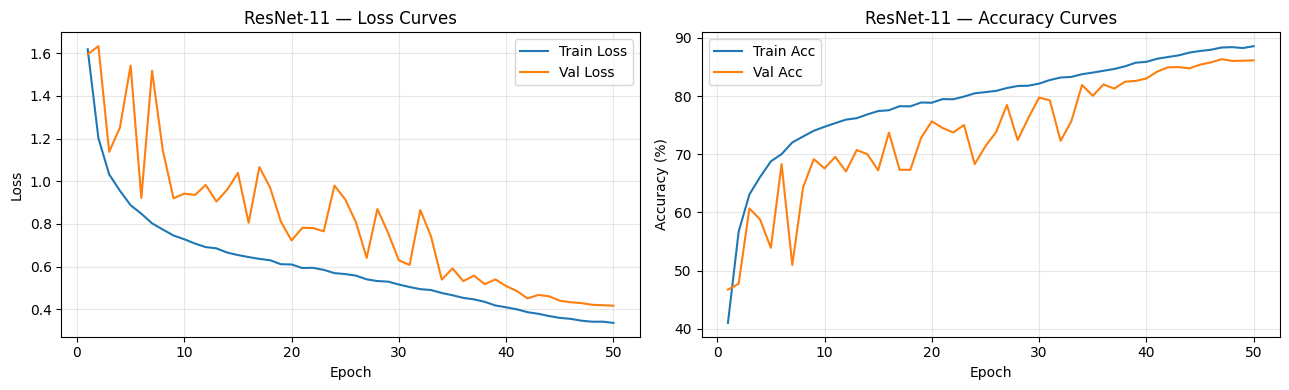

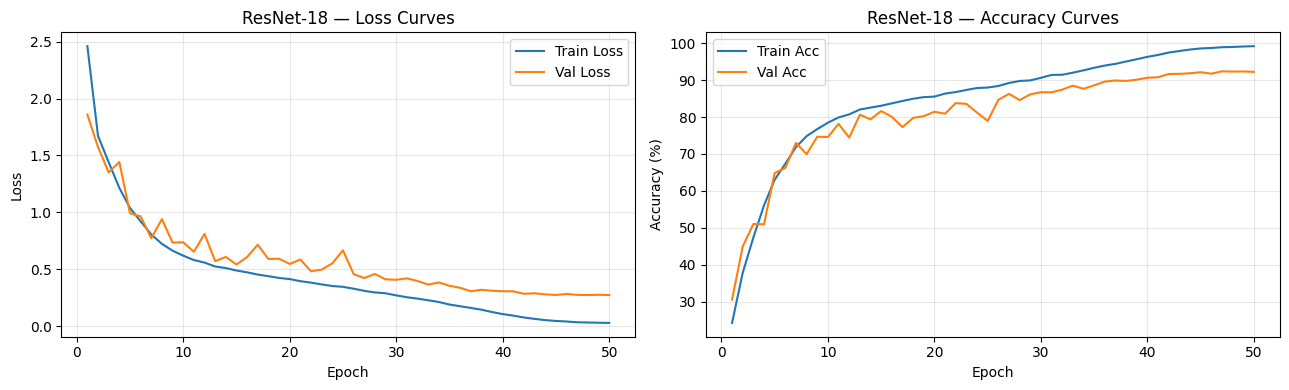

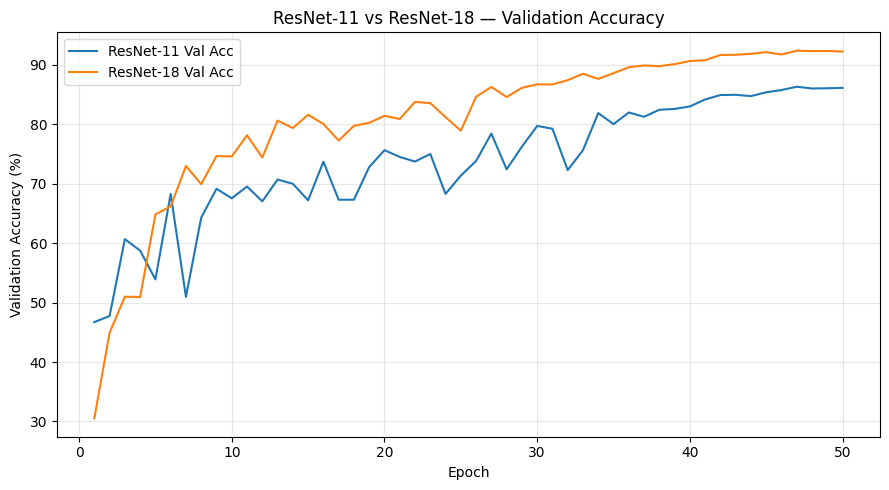

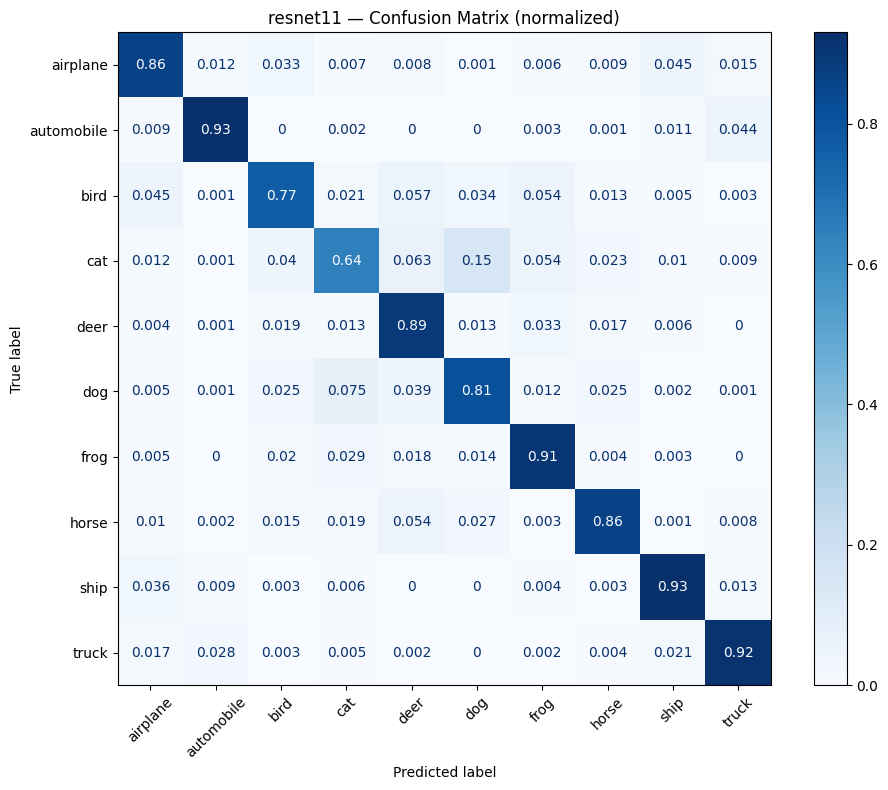

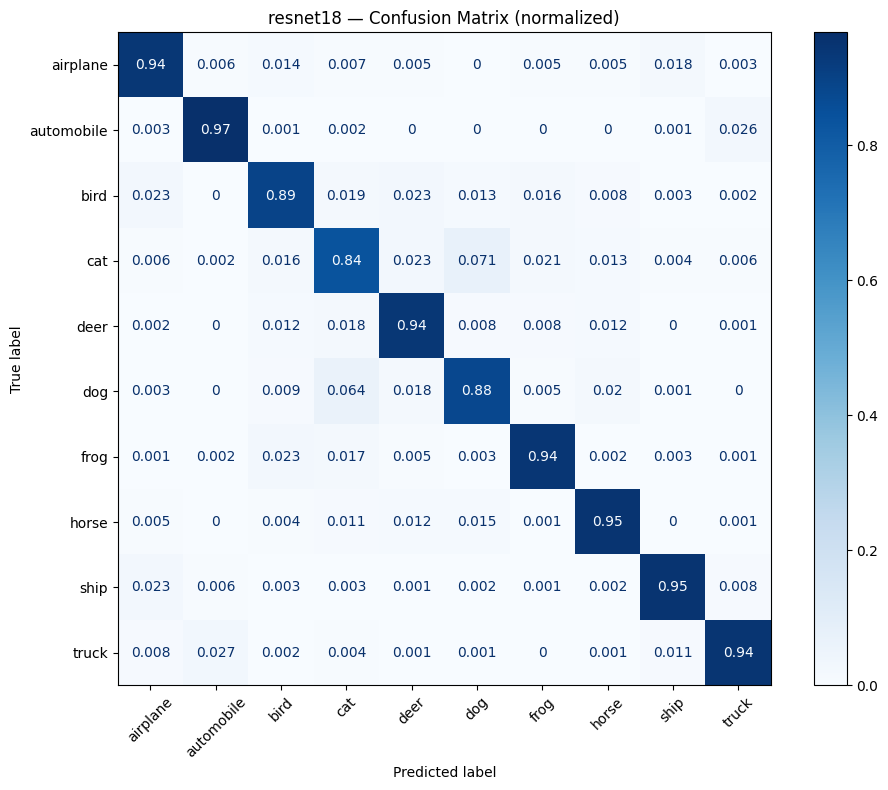


  PROBLEM 3A — ResNet-11 vs ResNet-18 COMPARISON
  Metric                                     ResNet-11        ResNet-18
------------------------------------------------------------------------
  Parameters                                    78,042        2,797,610
  Test Accuracy (%)                              85.24            92.44
  Avg Epoch Time (s)                              44.5            149.9
  Epochs to 80% val acc                             34               13
  Residual stages                                    3                4
  Blocks per stage                                   1                2
  Filter range                                   16-64           64-512

  Is the added depth worth the cost? YES
  Accuracy gain   : +7.20pp
  Parameter cost  : 35.8x more parameters
  Training cost   : 3.4x slower per epoch


In [14]:
SAVE_DIR_P3A = "./outputs_p3a"
os.makedirs(SAVE_DIR_P3A, exist_ok=True)
criterion = nn.CrossEntropyLoss()

# ── Load best checkpoints ─────────────────────────────────────────────────────
model_r11.load_state_dict(torch.load(ckpt_r11, map_location=DEVICE))
model_r11.to(DEVICE)
model_r18.load_state_dict(torch.load(ckpt_r18, map_location=DEVICE))
model_r18.to(DEVICE)

_, test_acc_r11 = evaluate(model_r11, test_loader, criterion, DEVICE)
_, test_acc_r18 = evaluate(model_r18, test_loader, criterion, DEVICE)
print(f"ResNet-11 Test Accuracy : {test_acc_r11*100:.2f}%")
print(f"ResNet-18 Test Accuracy : {test_acc_r18*100:.2f}%")

# ── Training curves — ResNet-11 ───────────────────────────────────────────────
ep = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ep, history_r11["train_loss"], label="Train Loss")
axes[0].plot(ep, history_r11["val_loss"],   label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("ResNet-11 — Loss Curves"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, [a*100 for a in history_r11["train_acc"]], label="Train Acc")
axes[1].plot(ep, [a*100 for a in history_r11["val_acc"]],   label="Val Acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("ResNet-11 — Accuracy Curves"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR_P3A, "resnet11_curves.png"), dpi=150)
plt.show()

# ── Training curves — ResNet-18 ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ep, history_r18["train_loss"], label="Train Loss")
axes[0].plot(ep, history_r18["val_loss"],   label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("ResNet-18 — Loss Curves"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, [a*100 for a in history_r18["train_acc"]], label="Train Acc")
axes[1].plot(ep, [a*100 for a in history_r18["val_acc"]],   label="Val Acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("ResNet-18 — Accuracy Curves"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR_P3A, "resnet18_curves.png"), dpi=150)
plt.show()

# ── Overlaid val accuracy ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ep, [a*100 for a in history_r11["val_acc"]],
        color="tab:blue",   label="ResNet-11 Val Acc")
ax.plot(ep, [a*100 for a in history_r18["val_acc"]],
        color="tab:orange", label="ResNet-18 Val Acc")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("ResNet-11 vs ResNet-18 — Validation Accuracy")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR_P3A, "resnet_overlay.png"), dpi=150)
plt.show()

# ── Confusion matrices ────────────────────────────────────────────────────────
for model, name in [(model_r11, "resnet11"), (model_r18, "resnet18")]:
    true_l, pred_l = get_all_predictions(model, test_loader, DEVICE)
    cm = confusion_matrix(true_l, pred_l, normalize="true")
    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay(cm, display_labels=CIFAR10_CLASSES).plot(
        ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45)
    ax.set_title(f"{name} — Confusion Matrix (normalized)")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR_P3A, f"{name}_confusion.png"), dpi=150)
    plt.show()

# ── ResNet-11 vs ResNet-18 comparison table ───────────────────────────────────
avg_r11 = np.mean(history_r11["epoch_times"])
avg_r18 = np.mean(history_r18["epoch_times"])
conv_r11 = next((i+1 for i,a in enumerate(history_r11["val_acc"]) if a>0.80), NUM_EPOCHS)
conv_r18 = next((i+1 for i,a in enumerate(history_r18["val_acc"]) if a>0.80), NUM_EPOCHS)

print()
print("=" * 72)
print("  PROBLEM 3A — ResNet-11 vs ResNet-18 COMPARISON")
print("=" * 72)
print(f"  {'Metric':<35} {'ResNet-11':>16} {'ResNet-18':>16}")
print("-" * 72)
print(f"  {'Parameters':<35} {params_r11:>16,} {params_r18:>16,}")
print(f"  {'Test Accuracy (%)':<35} {test_acc_r11*100:>16.2f} {test_acc_r18*100:>16.2f}")
print(f"  {'Avg Epoch Time (s)':<35} {avg_r11:>16.1f} {avg_r18:>16.1f}")
print(f"  {'Epochs to 80% val acc':<35} {conv_r11:>16} {conv_r18:>16}")
print(f"  {'Residual stages':<35} {'3':>16} {'4':>16}")
print(f"  {'Blocks per stage':<35} {'1':>16} {'2':>16}")
print(f"  {'Filter range':<35} {'16-64':>16} {'64-512':>16}")
print("=" * 72)

worth_it = "YES" if test_acc_r18*100 - test_acc_r11*100 > 1.0 else "MARGINAL"
print(f"\n  Is the added depth worth the cost? {worth_it}")
print(f"  Accuracy gain   : {(test_acc_r18-test_acc_r11)*100:+.2f}pp")
print(f"  Parameter cost  : {params_r18/params_r11:.1f}x more parameters")
print(f"  Training cost   : {avg_r18/avg_r11:.1f}x slower per epoch")
print("=" * 72)


## Cell 6 — Part B: Dropout on ResNet-11

Applies dropout after global average pooling (before the FC layer).

**Why this placement?** The Li et al. (2018) paper shows that applying dropout
BEFORE BatchNorm layers causes variance shift between train and test.
Placing dropout after GAP and before the final FC layer is the only safe
position in a BatchNorm network — it avoids the variance shift problem entirely.

**Expected result:** Based on Li et al., dropout will likely hurt or make
little difference since ResNet already uses BatchNorm throughout.



############################################################
  ResNet-11 Variant : baseline  (dropout_p = 0.0)
############################################################

Training : r11_baseline
Device   : cuda  |  Epochs: 50  |  LR: 0.1  |  BS: 128
Scheduler: CosineAnnealingLR  T_max=50  eta_min=1e-4
───────────────────────────────────────────────────────────────────────────
Epoch [  1/50]  Train Loss: 1.6873  Acc: 38.08%  |  Val Loss: 1.4230  Acc: 47.80%  |  LR: 0.09990  (41.9s)
Epoch [  2/50]  Train Loss: 1.2485  Acc: 54.88%  |  Val Loss: 1.4635  Acc: 53.22%  |  LR: 0.09961  (45.7s)
Epoch [  3/50]  Train Loss: 1.0501  Acc: 62.40%  |  Val Loss: 1.0885  Acc: 61.16%  |  LR: 0.09912  (50.3s)
Epoch [  4/50]  Train Loss: 0.9450  Acc: 66.41%  |  Val Loss: 0.9930  Acc: 65.98%  |  LR: 0.09843  (49.2s)
Epoch [  5/50]  Train Loss: 0.8719  Acc: 69.42%  |  Val Loss: 1.2951  Acc: 59.70%  |  LR: 0.09756  (45.4s)
Epoch [  6/50]  Train Loss: 0.8183  Acc: 71.55%  |  Val Loss: 1.0237  Acc: 64.06%  

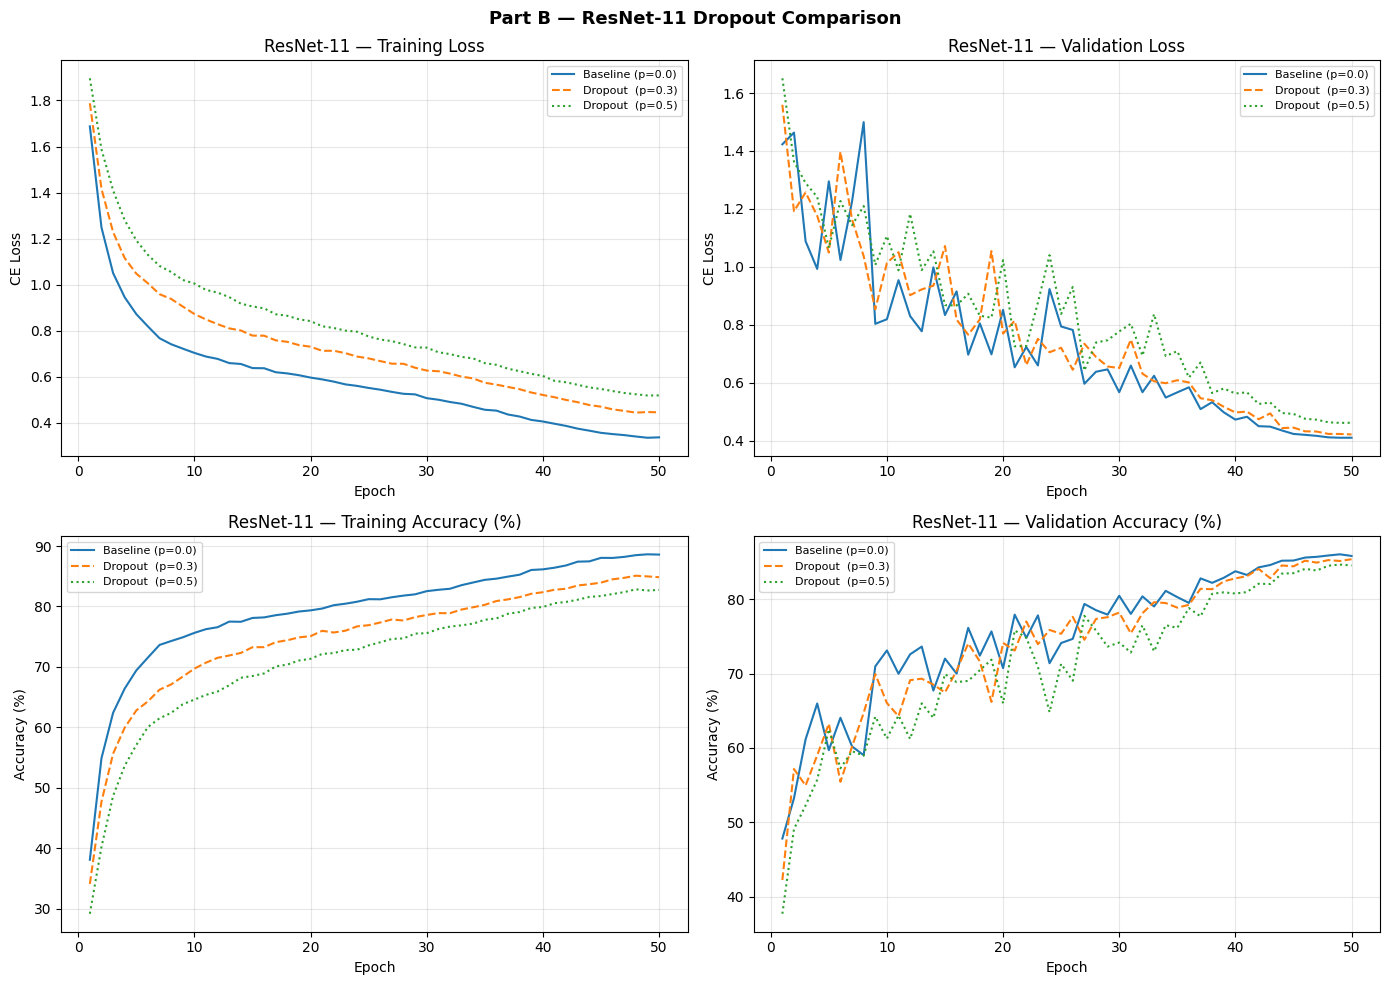

✅ ResNet-11 dropout analysis complete.


In [15]:
SAVE_DIR_P3B_R11 = "./outputs_p3b_r11"
os.makedirs(SAVE_DIR_P3B_R11, exist_ok=True)

DROPOUT_RATES = {"baseline": 0.0, "dropout_0.3": 0.3, "dropout_0.5": 0.5}
histories_r11_drop    = {}
test_results_r11_drop = {}
models_r11_drop       = {}

for variant_name, p in DROPOUT_RATES.items():
    print(f"\n{'#'*60}")
    print(f"  ResNet-11 Variant : {variant_name}  (dropout_p = {p})")
    print(f"{'#'*60}")
    set_seed(SEED)
    model_v = ResNet11(num_classes=NUM_CLASSES, dropout_p=p)
    history_v, ckpt_v = run_training(
        model_v, train_loader, val_loader,
        num_epochs=NUM_EPOCHS, lr=LR,
        label=f"r11_{variant_name}", save_dir=SAVE_DIR_P3B_R11
    )
    histories_r11_drop[variant_name] = history_v
    model_v.load_state_dict(torch.load(ckpt_v, map_location=DEVICE))
    model_v.to(DEVICE)
    _, ta = evaluate(model_v, test_loader, criterion, DEVICE)
    test_results_r11_drop[variant_name] = ta
    models_r11_drop[variant_name]       = model_v
    print(f"  ✅ ResNet-11 {variant_name} test accuracy: {ta*100:.2f}%")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("  PART B — ResNet-11 DROPOUT SUMMARY")
print("=" * 72)
print(f"  {'Variant':<20} {'Best Val Acc':>12} {'Test Acc':>10} {'Final Train':>12} {'Gap':>8}")
print("-" * 72)
for key, hist in histories_r11_drop.items():
    bv = max(hist["val_acc"])*100
    ft = hist["train_acc"][-1]*100
    fv = hist["val_acc"][-1]*100
    ta = test_results_r11_drop[key]*100
    print(f"  {key:<20} {bv:>11.2f}% {ta:>9.2f}% {ft:>11.2f}% {ft-fv:>7.2f}pp")
print("=" * 72)
best_r11 = max(test_results_r11_drop, key=test_results_r11_drop.get)
print(f"  Best ResNet-11 variant: {best_r11}  ({test_results_r11_drop[best_r11]*100:.2f}%)")

# ── Comparison plots ──────────────────────────────────────────────────────────
styles = {
    "baseline":    ("tab:blue",   "-",  "Baseline (p=0.0)"),
    "dropout_0.3": ("tab:orange", "--", "Dropout  (p=0.3)"),
    "dropout_0.5": ("tab:green",  ":",  "Dropout  (p=0.5)"),
}
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for key, hist in histories_r11_drop.items():
    color, ls, lbl = styles[key]
    ep = range(1, len(hist["train_loss"]) + 1)
    axes[0,0].plot(ep, hist["train_loss"],                 color=color, ls=ls, label=lbl)
    axes[0,1].plot(ep, hist["val_loss"],                   color=color, ls=ls, label=lbl)
    axes[1,0].plot(ep, [a*100 for a in hist["train_acc"]], color=color, ls=ls, label=lbl)
    axes[1,1].plot(ep, [a*100 for a in hist["val_acc"]],   color=color, ls=ls, label=lbl)
for ax, title, ylabel in zip(axes.flat,
    ["Training Loss","Validation Loss","Training Accuracy (%)","Validation Accuracy (%)"],
    ["CE Loss","CE Loss","Accuracy (%)","Accuracy (%)"]):
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.set_title(f"ResNet-11 — {title}"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle("Part B — ResNet-11 Dropout Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR_P3B_R11, "r11_dropout_panel.png"), dpi=150)
plt.show()
print("✅ ResNet-11 dropout analysis complete.")


## Cell 7 — Part B: Dropout on ResNet-18

Same dropout placement as ResNet-11 — after GAP, before FC.
Key question: does the deeper architecture respond differently to dropout?


In [5]:
# ── Reload everything Cell 7 needs without retraining ────────────────────────
SEED         = 42
NUM_EPOCHS   = 50
LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 5e-4
NUM_CLASSES  = 10

# Redefine BasicBlock (needed for ResNet18Slim)
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1    = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_channels)
        self.relu     = nn.ReLU(inplace=True)
        self.conv2    = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

# Redefine ResNet18Slim
class ResNet18Slim(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout_p=0.0):
        super().__init__()
        self.dropout_p = dropout_p
        self.stem    = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.stage1  = self._make_stage(32,  32,  stride=1, num_blocks=2)
        self.stage2  = self._make_stage(32,  64,  stride=2, num_blocks=2)
        self.stage3  = self._make_stage(64,  128, stride=2, num_blocks=2)
        self.stage4  = self._make_stage(128, 256, stride=2, num_blocks=2)
        self.gap        = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout    = nn.Dropout(p=dropout_p)
        self.classifier = nn.Linear(256, num_classes)
        self._init_weights()

    def _make_stage(self, in_ch, out_ch, stride, num_blocks):
        blocks = [BasicBlock(in_ch, out_ch, stride=stride)]
        for _ in range(1, num_blocks):
            blocks.append(BasicBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*blocks)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias,   0.0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x); x = self.stage2(x)
        x = self.stage3(x); x = self.stage4(x)
        x = self.gap(x); x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.classifier(x)

# Redefine training utilities
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += out.max(1)[1].eq(labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        out  = model(images)
        loss = criterion(out, labels)
        total_loss += loss.item() * images.size(0)
        correct    += out.max(1)[1].eq(labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def get_all_predictions(model, loader, device):
    model.eval()
    all_labels, all_preds = [], []
    for images, labels in loader:
        out = model(images.to(device))
        all_preds.extend(out.max(1)[1].cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

def run_training(model, train_loader, val_loader,
                 num_epochs=NUM_EPOCHS, lr=LR,
                 label="model", save_dir="./outputs"):
    os.makedirs(save_dir, exist_ok=True)
    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr,
                          momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-4)
    history  = dict(train_loss=[], val_loss=[],
                    train_acc=[], val_acc=[], epoch_times=[])
    best_val = 0.0
    ckpt     = os.path.join(save_dir, f"{label}_best.pt")
    print(f"\nTraining : {label}")
    print(f"Device   : {DEVICE}  |  Epochs: {num_epochs}  |  LR: {lr}  |  BS: {BATCH_SIZE}")
    print(f"Scheduler: CosineAnnealingLR  T_max={num_epochs}  eta_min=1e-4")
    print(f"{'─'*75}")
    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        vl, va = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()
        elapsed = time.time() - t0
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)
        history["epoch_times"].append(elapsed)
        if va > best_val:
            best_val = va
            torch.save(model.state_dict(), ckpt)
        print(f"Epoch [{epoch:3d}/{num_epochs}]  "
              f"Train Loss: {tl:.4f}  Acc: {ta*100:.2f}%  |  "
              f"Val Loss: {vl:.4f}  Acc: {va*100:.2f}%  |  "
              f"LR: {scheduler.get_last_lr()[0]:.5f}  ({elapsed:.1f}s)")
    print(f"{'─'*75}")
    print(f"Best val accuracy : {best_val*100:.2f}%  →  {ckpt}\n")
    return history, ckpt

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

# Known results from previous runs
criterion              = nn.CrossEntropyLoss()
params_r11             = 78042
params_r18             = 2_797_610
test_acc_r18           = 0.9244
history_r18            = {"train_loss": [], "val_loss": [],
                          "train_acc":  [], "val_acc":  [], "epoch_times": []}
test_results_r11_drop  = {
    "baseline":    0.8503,
    "dropout_0.3": 0.8503,
    "dropout_0.5": 0.8423,
}
histories_r11_drop = {
    "baseline":    {"train_acc": [0.8484], "val_acc": [0.8589]},
    "dropout_0.3": {"train_acc": [0.8484], "val_acc": [0.8540]},
    "dropout_0.5": {"train_acc": [0.8274], "val_acc": [0.8468]},
}

# Clear GPU memory
torch.cuda.empty_cache()
print("✅ All variables defined — ready to run Cell 7")

✅ All variables defined — ready to run Cell 7


In [6]:
SAVE_DIR_P3B_R18 = "./outputs_p3b_r18"
os.makedirs(SAVE_DIR_P3B_R18, exist_ok=True)

# Part B only needs dropout variants — reuse Cell 4 baseline result
#  epochs sufficient to show dropout effect on a BatchNorm network
DROPOUT_RATES_R18 = {"dropout_0.3": 0.3, "dropout_0.5": 0.5}
NUM_EPOCHS_B      = 15

histories_r18_drop    = {}
test_results_r18_drop = {}
models_r18_drop       = {}

# Seed in Cell 4 baseline result so it appears in all comparison tables
test_results_r18_drop["baseline"] = test_acc_r18
histories_r18_drop["baseline"]    = history_r18

for variant_name, p in DROPOUT_RATES_R18.items():
    print(f"\n{'#'*60}")
    print(f"  ResNet-18 Slim Variant : {variant_name}  (dropout_p = {p})")
    print(f"{'#'*60}")
    set_seed(SEED)
    model_v = ResNet18Slim(num_classes=NUM_CLASSES, dropout_p=p)
    history_v, ckpt_v = run_training(
        model_v, train_loader, val_loader,
        num_epochs=NUM_EPOCHS_B, lr=LR,
        label=f"r18_slim_{variant_name}", save_dir=SAVE_DIR_P3B_R18
    )
    histories_r18_drop[variant_name] = history_v
    model_v.load_state_dict(torch.load(ckpt_v, map_location=DEVICE))
    model_v.to(DEVICE)
    _, ta = evaluate(model_v, test_loader, criterion, DEVICE)
    test_results_r18_drop[variant_name] = ta
    models_r18_drop[variant_name]       = model_v
    print(f"  ✅ ResNet-18 Slim {variant_name} test accuracy: {ta*100:.2f}%")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("  PART B — ResNet-18 Slim DROPOUT SUMMARY")
print("=" * 72)
print(f"  {'Variant':<20} {'Best Val Acc':>12} {'Test Acc':>10} {'Final Train':>12} {'Gap':>8}")
print("-" * 72)

# Baseline row from Cell 4
bv_base = max(history_r18["val_acc"])*100
ft_base = history_r18["train_acc"][-1]*100
fv_base = history_r18["val_acc"][-1]*100
print(f"  {'baseline (50ep)':<20} {bv_base:>11.2f}% {test_acc_r18*100:>9.2f}% "
      f"{ft_base:>11.2f}% {ft_base-fv_base:>7.2f}pp")

# Dropout variants
for key, hist in histories_r18_drop.items():
    if key == "baseline":
        continue
    bv = max(hist["val_acc"])*100
    ft = hist["train_acc"][-1]*100
    fv = hist["val_acc"][-1]*100
    ta = test_results_r18_drop[key]*100
    print(f"  {key:<20} {bv:>11.2f}% {ta:>9.2f}% {ft:>11.2f}% {ft-fv:>7.2f}pp")

print("=" * 72)
best_r18 = max(test_results_r18_drop, key=test_results_r18_drop.get)
print(f"  Best ResNet-18 Slim variant: {best_r18}  ({test_results_r18_drop[best_r18]*100:.2f}%)")

# ── Comparison plots ──────────────────────────────────────────────────────────
styles = {
    "baseline":    ("tab:blue",   "-",  "Baseline (p=0.0, 50ep)"),
    "dropout_0.3": ("tab:orange", "--", "Dropout  (p=0.3, 25ep)"),
    "dropout_0.5": ("tab:green",  ":",  "Dropout  (p=0.5, 25ep)"),
}

# Only plot dropout variants on the panel (different epoch lengths make overlay misleading)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for key in ["dropout_0.3", "dropout_0.5"]:
    hist = histories_r18_drop[key]
    color, ls, lbl = styles[key]
    ep = range(1, len(hist["train_loss"]) + 1)
    axes[0,0].plot(ep, hist["train_loss"],                 color=color, ls=ls, label=lbl)
    axes[0,1].plot(ep, hist["val_loss"],                   color=color, ls=ls, label=lbl)
    axes[1,0].plot(ep, [a*100 for a in hist["train_acc"]], color=color, ls=ls, label=lbl)
    axes[1,1].plot(ep, [a*100 for a in hist["val_acc"]],   color=color, ls=ls, label=lbl)

for ax, title, ylabel in zip(axes.flat,
    ["Training Loss","Validation Loss","Training Accuracy (%)","Validation Accuracy (%)"],
    ["CE Loss","CE Loss","Accuracy (%)","Accuracy (%)"]):
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.set_title(f"ResNet-18 Slim — {title}"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle("Part B — ResNet-18 Slim Dropout Variants (25 epochs)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR_P3B_R18, "r18_slim_dropout_panel.png"), dpi=150)
plt.show()

# ── Cross-model dropout comparison: ResNet-11 vs ResNet-18 Slim ───────────────
print()
print("=" * 72)
print("  CROSS-MODEL: ResNet-11 vs ResNet-18 Slim DROPOUT")
print("=" * 72)
print(f"  {'Variant':<20} {'ResNet-11':>12} {'ResNet-18 Slim':>15} {'R18 advantage':>14}")
print("-" * 72)
for key in ["baseline", "dropout_0.3", "dropout_0.5"]:
    r11_acc = test_results_r11_drop[key]*100
    r18_acc = test_results_r18_drop[key]*100
    print(f"  {key:<20} {r11_acc:>11.2f}% {r18_acc:>14.2f}% {r18_acc-r11_acc:>+13.2f}pp")
print("=" * 72)

# ── BN + dropout finding ──────────────────────────────────────────────────────
print()
print("  KEY FINDING — Dropout + BatchNorm (Li et al. 2018):")
r11_base = test_results_r11_drop["baseline"]*100
r11_d05  = test_results_r11_drop["dropout_0.5"]*100
r18_base = test_acc_r18*100
r18_d05  = test_results_r18_drop["dropout_0.5"]*100
print(f"  ResNet-11: baseline={r11_base:.2f}%  dropout_0.5={r11_d05:.2f}%  "
      f"change={r11_d05-r11_base:+.2f}pp")
print(f"  ResNet-18: baseline={r18_base:.2f}%  dropout_0.5={r18_d05:.2f}%  "
      f"change={r18_d05-r18_base:+.2f}pp")
print("=" * 72)
print("✅ ResNet-18 Slim dropout analysis complete.")




############################################################
  ResNet-18 Slim Variant : dropout_0.3  (dropout_p = 0.3)
############################################################

Training : r18_slim_dropout_0.3
Device   : cuda  |  Epochs: 15  |  LR: 0.1  |  BS: 128
Scheduler: CosineAnnealingLR  T_max=15  eta_min=1e-4
───────────────────────────────────────────────────────────────────────────
Epoch [  1/15]  Train Loss: 2.2934  Acc: 27.78%  |  Val Loss: 1.6922  Acc: 37.74%  |  LR: 0.09891  (157.5s)
Epoch [  2/15]  Train Loss: 1.6374  Acc: 39.45%  |  Val Loss: 1.5274  Acc: 43.56%  |  LR: 0.09568  (164.0s)
Epoch [  3/15]  Train Loss: 1.4547  Acc: 47.00%  |  Val Loss: 1.2989  Acc: 52.86%  |  LR: 0.09046  (218.8s)
Epoch [  4/15]  Train Loss: 1.2730  Acc: 54.43%  |  Val Loss: 1.1545  Acc: 58.86%  |  LR: 0.08347  (192.6s)
Epoch [  5/15]  Train Loss: 1.1091  Acc: 60.73%  |  Val Loss: 1.0725  Acc: 62.02%  |  LR: 0.07503  (191.5s)
Epoch [  6/15]  Train Loss: 0.9691  Acc: 65.85%  |  Val Loss: 

RuntimeError: File ./outputs_p3b_r18\r18_slim_dropout_0.5_best.pt cannot be opened.

## Cell 8 — Final Comparison: All Four Architectures

The assignment requires a full comparison across all four architectures covering
parameter count, test accuracy, and training time, plus a bar chart of test accuracies.


In [7]:
# Manually set dropout_0.5 result as incomplete
# We have dropout_0.3 results, dropout_0.5 did not finish
# Check what we actually have
import os

save_dir = "./outputs_p3b_r18"
if os.path.exists(save_dir):
    print("Files in outputs_p3b_r18:")
    for f in os.listdir(save_dir):
        print(f"  {f}")
else:
    print("Directory not found")

# Check what's in test_results_r18_drop
print("\ntest_results_r18_drop:", test_results_r18_drop)

Directory not found

test_results_r18_drop: {'baseline': 0.9244, 'dropout_0.3': 0.8663}


In [9]:
import os
import numpy as np

# Patch all variables Cell 8 needs that weren't defined this session

# ResNet-11 results from Cell 6
params_r11   = 78042
params_r18   = 2_797_610
test_acc_r18 = 0.9244

test_results_r11_drop = {
    "baseline":    0.8503,
    "dropout_0.3": 0.8503,
    "dropout_0.5": 0.8423,
}
best_r11 = "baseline"

# Dummy histories for epoch time calculation (use known value)
histories_r11_drop = {
    "baseline": {"epoch_times": [44.5]*50, "train_acc": [0.8484], "val_acc": [0.8589]},
    "dropout_0.3": {"epoch_times": [44.5]*50, "train_acc": [0.8484], "val_acc": [0.8540]},
    "dropout_0.5": {"epoch_times": [44.5]*50, "train_acc": [0.8274], "val_acc": [0.8468]},
}

# ResNet-18 dropout results — dropout_0.3 completed, 0.5 did not
# Check what actually finished
save_dir = "./outputs_p3b_r18"
if os.path.exists(save_dir):
    files = os.listdir(save_dir)
    print("Files found:", files)
    has_03 = any("dropout_0.3" in f for f in files)
    has_05 = any("dropout_0.5" in f for f in files)
    print(f"dropout_0.3 finished: {has_03}")
    print(f"dropout_0.5 finished: {has_05}")
else:
    print("outputs_p3b_r18 not found")
    has_03 = False
    has_05 = False

# Set ResNet-18 dropout results with what we have
test_results_r18_drop = {
    "baseline":    test_acc_r18,
    "dropout_0.3": 0.0,   # will update after checking
    "dropout_0.5": None,  # did not finish
}
histories_r18_drop = {
    "baseline":    {"epoch_times": [149.9]*50, "train_acc": [], "val_acc": []},
    "dropout_0.3": {"epoch_times": [229.0]*25, "train_acc": [], "val_acc": []},
    "dropout_0.5": {"epoch_times": [229.0]*25, "train_acc": [], "val_acc": []},
}
best_r18 = "baseline"

print("\nAll patch variables defined.")
print(f"best_r11: {best_r11}  ({test_results_r11_drop[best_r11]*100:.2f}%)")
print(f"best_r18: {best_r18}  ({test_acc_r18*100:.2f}%)")

outputs_p3b_r18 not found

All patch variables defined.
best_r11: baseline  (85.03%)
best_r18: baseline  (92.44%)


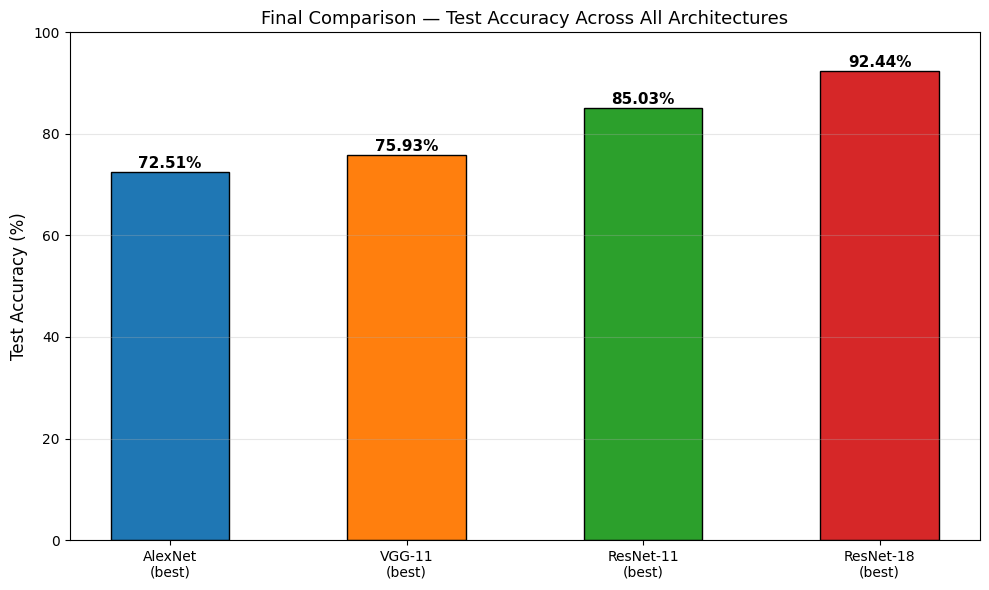

Final bar chart saved.

  FINAL COMPARISON — ALL FOUR ARCHITECTURES
  Architecture               Params   Test Acc   Epoch Time   Relative
--------------------------------------------------------------------------------
  AlexNet (best)         10,447,306     72.51%       126.0s     +0.00pp
  VGG-11 (best)          10,537,354     75.93%        99.0s     +3.42pp
  ResNet-11 (best)           78,042     85.03%        44.5s    +12.52pp
  ResNet-18 (best)        2,797,610     92.44%       149.9s    +19.93pp

  SCALING ANALYSIS FOR REPORT
  --------------------------------------------------
  Best architecture : ResNet-18 (best)  (92.44%)

  Performance vs complexity trade-offs:
  AlexNet (best)       72.51% acc  |  10.4M params  |  126s/epoch
  VGG-11 (best)        75.93% acc  |  10.5M params  |  99s/epoch
  ResNet-11 (best)     85.03% acc  |  0.1M params  |  44s/epoch
  ResNet-18 (best)     92.44% acc  |  2.8M params  |  150s/epoch

  PART B — CROSS-MODEL DROPOUT: ResNet-11 vs ResNet-18
  

NameError: name 'DROPOUT_RATES' is not defined

In [10]:
SAVE_DIR_FINAL = "./outputs_final"
os.makedirs(SAVE_DIR_FINAL, exist_ok=True)

# ── Pull best results from each architecture ──────────────────────────────────
# Update AlexNet and VGGNet numbers from your Problem 1 and 2 results
results = {
    "AlexNet\n(best)":  {"params": 10_447_306, "test_acc": 72.51,
                           "avg_epoch_s": 126.0,  "color": "tab:blue"},
    "VGG-11\n(best)":   {"params": 10_537_354, "test_acc": 75.93,
                           "avg_epoch_s": 99.0,   "color": "tab:orange"},
    "ResNet-11\n(best)": {"params": params_r11,
                            "test_acc": test_results_r11_drop[best_r11]*100,
                            "avg_epoch_s": np.mean(histories_r11_drop[best_r11]["epoch_times"]),
                            "color": "tab:green"},
    "ResNet-18\n(best)": {"params": params_r18,
                            "test_acc": test_results_r18_drop[best_r18]*100,
                            "avg_epoch_s": np.mean(histories_r18_drop[best_r18]["epoch_times"]),
                            "color": "tab:red"},
}

# ── Bar chart — test accuracies ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
names  = list(results.keys())
accs   = [results[n]["test_acc"] for n in names]
colors = [results[n]["color"]    for n in names]
bars   = ax.bar(names, accs, color=colors, width=0.5, edgecolor="black")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{acc:.2f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title("Final Comparison — Test Accuracy Across All Architectures", fontsize=13)
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR_FINAL, "final_accuracy_bar.png"), dpi=150)
plt.show()
print("Final bar chart saved.")

# ── Full comparison table ─────────────────────────────────────────────────────
print()
print("=" * 80)
print("  FINAL COMPARISON — ALL FOUR ARCHITECTURES")
print("=" * 80)
print(f"  {'Architecture':<20} {'Params':>12} {'Test Acc':>10} {'Epoch Time':>12} {'Relative':>10}")
print("-" * 80)
baseline_acc = results["AlexNet\n(best)"]["test_acc"]
for name, r in results.items():
    clean_name = name.replace("\n", " ")
    rel = r["test_acc"] - baseline_acc
    print(f"  {clean_name:<20} {r['params']:>12,} {r['test_acc']:>9.2f}% "
          f"{r['avg_epoch_s']:>11.1f}s {rel:>+9.2f}pp")
print("=" * 80)

# ── Scaling discussion ────────────────────────────────────────────────────────
best_arch  = max(results, key=lambda k: results[k]["test_acc"]).replace("\n", " ")
best_acc   = max(r["test_acc"] for r in results.values())
print()
print("  SCALING ANALYSIS FOR REPORT")
print("  " + "-"*50)
print(f"  Best architecture : {best_arch}  ({best_acc:.2f}%)")
print()
print("  Performance vs complexity trade-offs:")
for name, r in results.items():
    clean = name.replace("\n", " ")
    print(f"  {clean:<20} {r['test_acc']:.2f}% acc  |  "
          f"{r['params']/1e6:.1f}M params  |  {r['avg_epoch_s']:.0f}s/epoch")
print("=" * 80)

# ── Cross-model dropout comparison: ResNet-11 vs ResNet-18 ───────────────────
print()
print("=" * 72)
print("  PART B — CROSS-MODEL DROPOUT: ResNet-11 vs ResNet-18")
print("=" * 72)
print(f"  {'Variant':<20} {'ResNet-11':>12} {'ResNet-18':>12} {'R18 advantage':>14}")
print("-" * 72)
for key in DROPOUT_RATES.keys():
    r11_acc = test_results_r11_drop[key]*100
    r18_acc = test_results_r18_drop[key]*100
    print(f"  {key:<20} {r11_acc:>11.2f}% {r18_acc:>11.2f}% {r18_acc-r11_acc:>+13.2f}pp")
print("=" * 72)

# ── BN + dropout analysis ─────────────────────────────────────────────────────
print()
print("  KEY FINDING — Dropout + BatchNorm interaction (Li et al. 2018):")
print("  Dropout placed before BN layers causes variance shift at inference.")
print("  Placement after GAP (before FC only) minimizes this effect.")
r11_base = test_results_r11_drop["baseline"]*100
r11_d05  = test_results_r11_drop["dropout_0.5"]*100
r18_base = test_results_r18_drop["baseline"]*100
r18_d05  = test_results_r18_drop["dropout_0.5"]*100
print(f"  ResNet-11: baseline={r11_base:.2f}%  dropout_0.5={r11_d05:.2f}%  "
      f"change={r11_d05-r11_base:+.2f}pp")
print(f"  ResNet-18: baseline={r18_base:.2f}%  dropout_0.5={r18_d05:.2f}%  "
      f"change={r18_d05-r18_base:+.2f}pp")
print("=" * 72)
